# Árboles - Análisis
El objetivo de este notebook es analizar los resultados obtenidos del random search (ver `07-arboles-random_search.ipynb`) y elegir el mejor modelo para cada uno de los datasets

In [45]:
%load_ext autoreload
%autoreload 2
import pandas as pd
from sklearn import set_config
set_config(transform_output="pandas")

import sys
sys.path.append('..')

from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import TransformedTargetRegressor

from src.plots import plot_grid_search_results, plot_learning_curve, plot_cv_results
from src.pipeline import build_feature_pipeline, build_target_pipeline, build_base_pipeline
from src.config import TREE_BASED_CONFIG_NORMAL, TREE_BASED_CONFIG_OUTLIERS
from src.constants import DEV_SET_CLEAN_PATH, DEV_SET_CLEAN_NORMAL_PATH, DEV_SET_CLEAN_OUTLIERS_PATH, TARGET
from src.model_evaluation import evaluate_models_cv
from src.models.base_models import get_base_xgboost

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [5]:
# Función para agregar una columna con un ID único para cada configuración (nos va a servir para identificar a la configuración)
def add_id_to_results(results):
    results = results.reset_index(drop=True)
    results.insert(0, 'config_id', range(1, len(results) + 1))
    return results

# 1. Dataset Normal

In [6]:
df_normal = pd.read_csv("../" + DEV_SET_CLEAN_NORMAL_PATH)

X = df_normal.drop(columns=TARGET)
y = df_normal[TARGET]

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

feature_pipeline = build_feature_pipeline(TREE_BASED_CONFIG_NORMAL)
target_pipeline = build_target_pipeline(TREE_BASED_CONFIG_NORMAL)

## 1.1 XGBoost Normal

In [7]:
df_xgb_normal = pd.read_csv("../results/random_search/xgb_normal.csv")
df_xgb_normal = add_id_to_results(df_xgb_normal)

In [8]:
df_xgb_normal.head()

,config_id,Unnamed: 0,colsample_bytree,gamma,learning_rate,max_depth,min_child_weight,n_estimators,reg_lambda,subsample,mae_mean,mae_std,rmse_mean,rmse_std,train_mae_mean,train_mae_std,train_rmse_mean,train_rmse_std,overfit_gap_%
0,1,186,0.781516,0.118025,0.032049,14,1,900,1.243571,0.846858,2536.179023,7.113218,7578.451981,86.491500,710.087251,13.094990,1434.872651,35.966782,257.164421
1,2,344,0.874963,0.012249,0.101841,13,3,1000,4.041176,0.979075,2554.034769,8.899343,7708.597657,120.544520,444.458980,4.126351,1180.497651,26.906216,474.639029
2,3,404,0.885764,0.476234,0.078018,14,4,800,1.450228,0.948566,2570.628462,3.655595,7716.860477,78.086654,534.593406,12.549669,1275.375059,35.683866,380.856747
3,4,230,0.754584,0.282221,0.067535,14,2,1000,4.974332,0.623112,2577.988132,4.383098,7506.954430,170.200532,783.716909,24.160498,1622.422651,59.204782,228.943794
4,5,373,0.972243,0.248656,0.079075,13,1,500,1.509584,0.904435,2600.656313,4.330941,7778.217663,63.736702,724.049248,11.740528,1448.428024,33.170530,259.182240


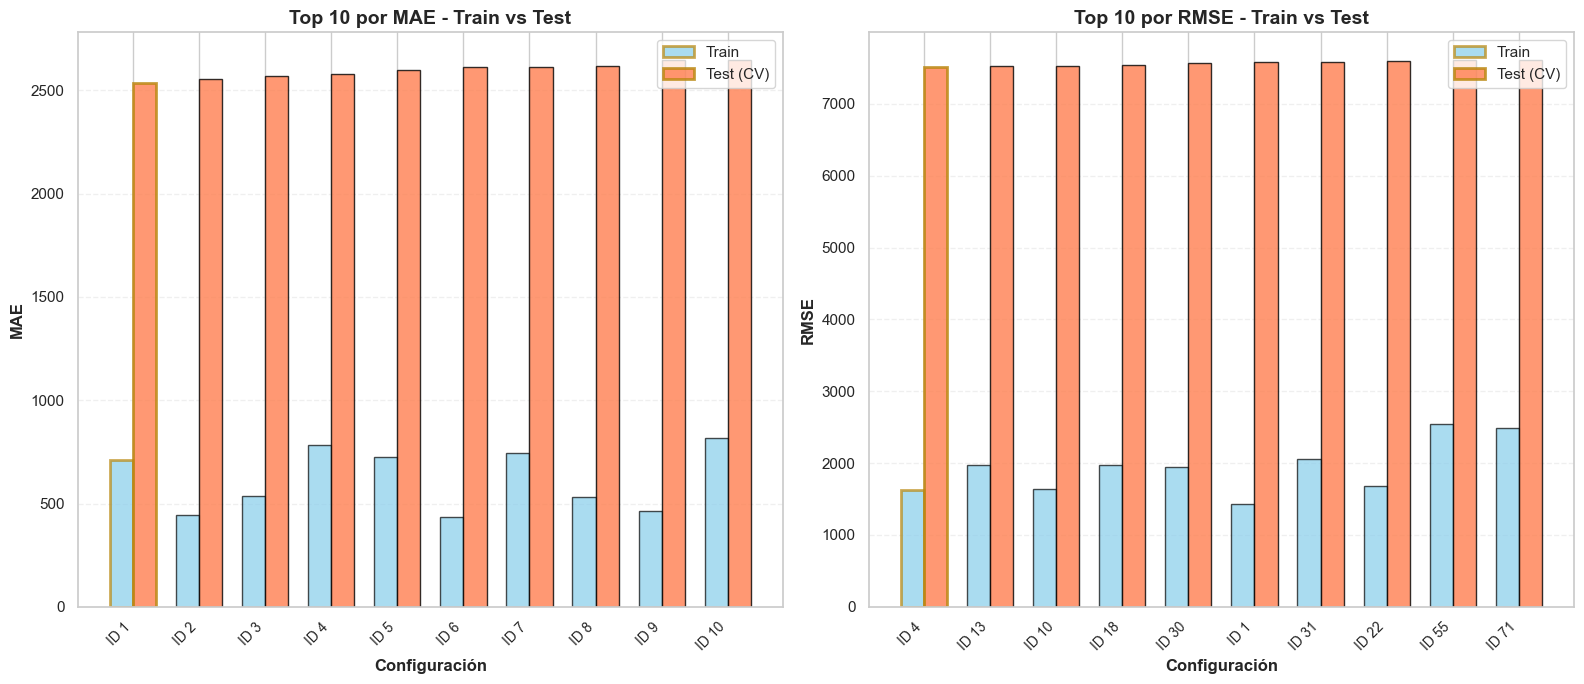

In [9]:
plot_grid_search_results(df_xgb_normal, top_n=10)

## 1.2 LightGBM normal

In [10]:
df_lgbm_normal = pd.read_csv("../results/random_search/lgbm_normal.csv")
df_lgbm_normal = add_id_to_results(df_lgbm_normal)

In [11]:
df_lgbm_normal.head()

,config_id,Unnamed: 0,colsample_bytree,learning_rate,min_child_samples,min_child_weight,n_estimators,num_leaves,reg_alpha,reg_lambda,subsample,mae_mean,mae_std,rmse_mean,rmse_std,train_mae_mean,train_mae_std,train_rmse_mean,train_rmse_std,overfit_gap_%
0,1,206,0.893446,0.233098,11,2.676075,1200,47,1.299066,3.801449,0.654844,3266.959748,12.630446,8115.816722,203.115698,2133.004746,12.157612,4204.854013,6.318926,53.162329
1,2,210,0.863477,0.283421,11,8.752062,1200,42,4.204358,0.192132,0.960705,3282.879378,15.609106,8149.226178,162.198427,2035.827903,10.838071,3894.974387,16.961308,61.255250
2,3,318,0.929324,0.236784,19,0.293868,1200,47,1.686728,0.096638,0.649747,3339.924916,13.888936,8222.666756,175.192574,2171.970417,14.300276,4354.730312,48.403119,53.773960
3,4,354,0.813716,0.166813,10,6.176688,1200,44,4.762336,1.133637,0.951736,3378.145397,22.035640,8286.718136,211.231516,2395.435511,7.742575,4820.745022,26.945398,41.024268
4,5,9,0.965984,0.256511,21,6.617960,1200,44,2.956489,1.373609,0.824497,3380.432346,6.452457,8315.887622,188.398544,2224.127466,15.459724,4471.706904,58.513340,51.989146


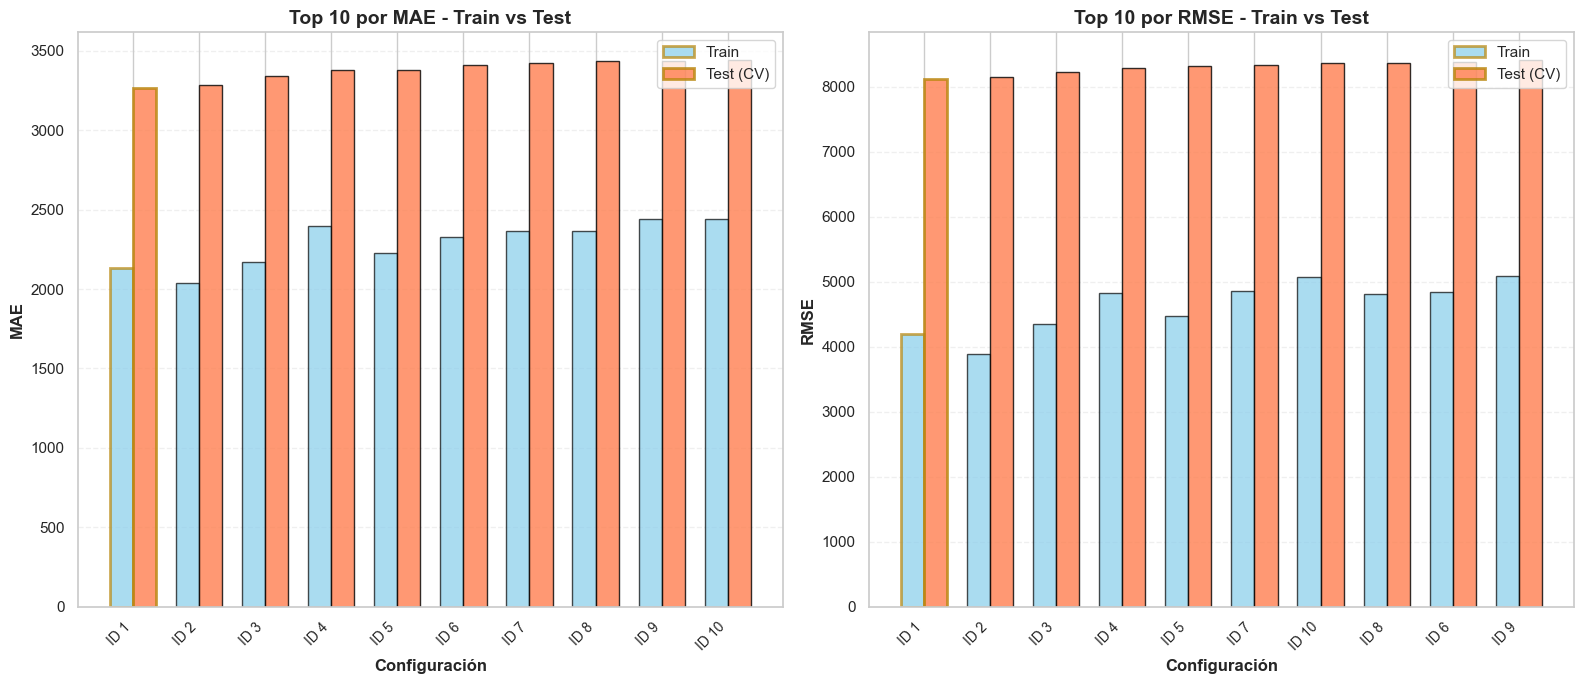

In [12]:
plot_grid_search_results(df_lgbm_normal, top_n=10)

## 1.3 Modelo final para el dataset normal
Los modelos que mejor funcionaron fueron son con XGBoost, aunqeu la diferencia entre las métricas en train y en test es demasiado grande.

El mejor modelo es el que tiene ID 4, pero la diferencia entre train y test es enorme. Veamos su learning curve para ver si está overfiteando


In [13]:
normal_winner_config = {
    'colsample_bytree': 0.7545843364636589,
    'gamma': 0.2822205453394412,
    'learning_rate': 0.0675347366775581,
    'max_depth': 14,
    'min_child_weight': 2,
    'n_estimators': 1000,
    'reg_lambda': 4.9743315858488355,
    'subsample': 0.6231122243985466
}

In [14]:
X_train_transformed = feature_pipeline.fit_transform(X_train)
X_val_transformed = feature_pipeline.transform(X_val)

y_train_transformed = target_pipeline.fit_transform(y_train.values.reshape(-1, 1)).ravel()
y_val_transformed = target_pipeline.transform(y_val.values.reshape(-1, 1)).ravel()

def eval_model(model):
    # Entrenar con eval_set para capturar learning curve
    eval_set = [(X_train_transformed, y_train_transformed),
                (X_val_transformed, y_val_transformed)]
    model.fit(
        X_train_transformed, y_train_transformed,
        eval_set=eval_set,
        verbose=False
    )

    return model.evals_result()

xgb_winner_results = eval_model(XGBRegressor(**normal_winner_config, random_state=42))

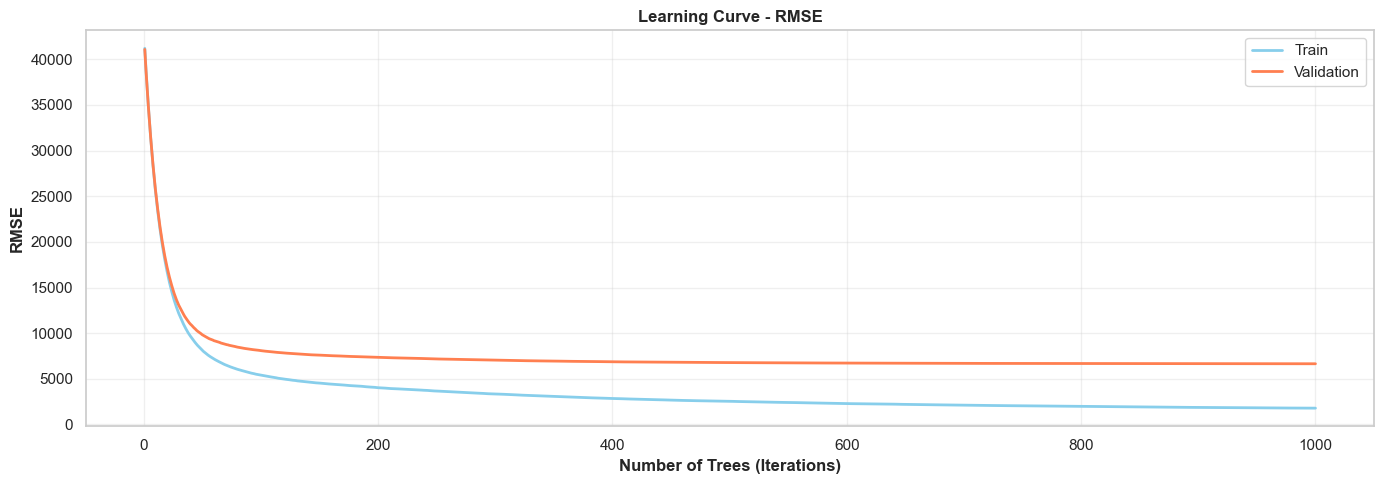

In [15]:
plot_learning_curve(xgb_winner_results)

El modelo si bien no está overfiteando (la loss en validación no aumenta), a partir de cierto punto deja de mejorar. Podemos probar hacer early stopping sin perder demasiada performance en validación. Probemos haciendo cross validation con distintas configuraciones:

In [16]:
def get_winner_config_with_n_estimators(n_estimators):
    result = normal_winner_config.copy()
    result['n_estimators'] = n_estimators
    result['random_state'] = 42
    return result


xgb_mini_gridsearch_params = {
    "100": XGBRegressor(**get_winner_config_with_n_estimators(100)),
    "200": XGBRegressor(**get_winner_config_with_n_estimators(200)),
    "300": XGBRegressor(**get_winner_config_with_n_estimators(300)),
    "400": XGBRegressor(**get_winner_config_with_n_estimators(400)),
    "500": XGBRegressor(**get_winner_config_with_n_estimators(500)),
    "600": XGBRegressor(**get_winner_config_with_n_estimators(600)),
    "700": XGBRegressor(**get_winner_config_with_n_estimators(700)),
    "800": XGBRegressor(**get_winner_config_with_n_estimators(800)),
    "900": XGBRegressor(**get_winner_config_with_n_estimators(900)),
    "1000": XGBRegressor(**get_winner_config_with_n_estimators(1000)),
    "1200": XGBRegressor(**get_winner_config_with_n_estimators(1000)),
    "1400": XGBRegressor(**get_winner_config_with_n_estimators(1000)),
}

In [17]:
xgb_mini_gridsearch_results = evaluate_models_cv(xgb_mini_gridsearch_params, X, y, feature_pipeline, target_pipeline, n_splits=5)



🔄 Ejecutando 5-Fold Cross-Validation...

Entrenando 100...
  ✓ MAE: 3,239 ± 28
  ✓ RMSE: 8,481 ± 229

Entrenando 200...
  ✓ MAE: 2,931 ± 17
  ✓ RMSE: 7,750 ± 218

Entrenando 300...
  ✓ MAE: 2,764 ± 15
  ✓ RMSE: 7,454 ± 213

Entrenando 400...
  ✓ MAE: 2,652 ± 13
  ✓ RMSE: 7,287 ± 211

Entrenando 500...
  ✓ MAE: 2,575 ± 13
  ✓ RMSE: 7,193 ± 212

Entrenando 600...
  ✓ MAE: 2,521 ± 13
  ✓ RMSE: 7,135 ± 213

Entrenando 700...
  ✓ MAE: 2,483 ± 15
  ✓ RMSE: 7,100 ± 213

Entrenando 800...
  ✓ MAE: 2,452 ± 16
  ✓ RMSE: 7,078 ± 216

Entrenando 900...
  ✓ MAE: 2,428 ± 16
  ✓ RMSE: 7,060 ± 214

Entrenando 1000...
  ✓ MAE: 2,409 ± 16
  ✓ RMSE: 7,049 ± 213

Entrenando 1200...
  ✓ MAE: 2,409 ± 16
  ✓ RMSE: 7,049 ± 213

Entrenando 1400...
  ✓ MAE: 2,409 ± 16
  ✓ RMSE: 7,049 ± 213



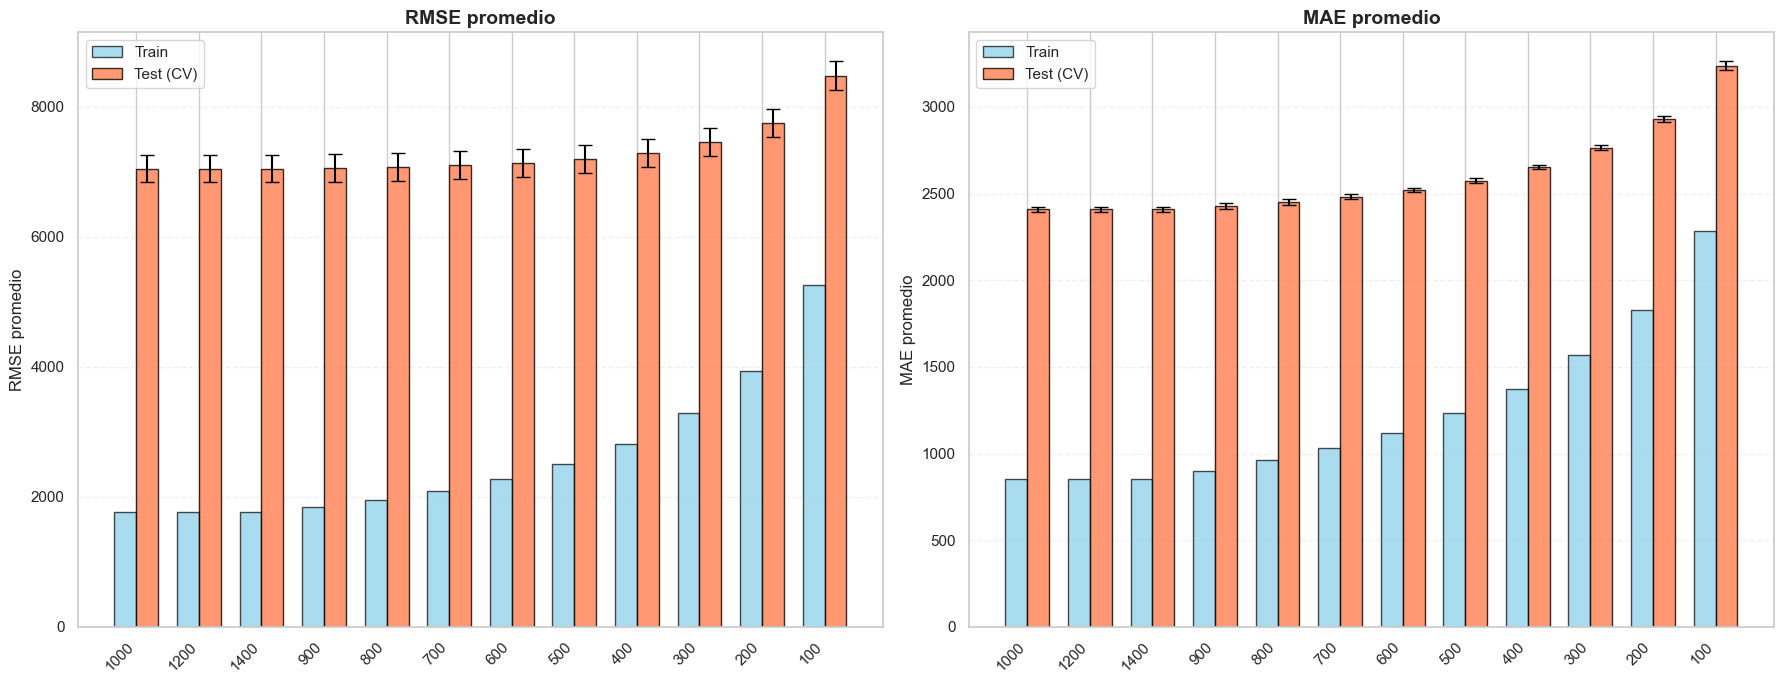

In [18]:
plot_cv_results(xgb_mini_gridsearch_results, vertical_layout=False)

## 1.4 Comparación final para el dataset normal

In [19]:
numeric_cols = X.select_dtypes(include=["number"]).columns.tolist()
categorical_cols = X.select_dtypes(include=["object", "bool"]).columns.tolist()

print(f"Numeric columns: {numeric_cols}")
print(f"Categorical columns: {categorical_cols}")

base_preprocessor = build_base_pipeline(numeric_cols, categorical_cols)
base_xgboost = get_base_xgboost(base_preprocessor)

Numeric columns: ['id_grid', 'STotalM2', 'SConstrM2', 'Dormitorios', 'Banos', 'Ambientes', 'Antiguedad', 'Cocheras', 'LONGITUDE', 'LATITUDE', 'year', 'mes_listing']
Categorical columns: ['Amoblado', 'Cisterna', 'BusinessCenter', 'Gimnasio', 'Laundry', 'Calefaccion', 'AireAC', 'Recepcion', 'Estacionamiento', 'Jacuzzi', 'AreaJuegosInfantiles', 'Seguridad', 'Pileta', 'EstacionamientoVisitas', 'CanchaTennis', 'ITE_ADD_CITY_NAME', 'ITE_ADD_STATE_NAME', 'ITE_ADD_NEIGHBORHOOD_NAME', 'ITE_TIPO_PROD', 'SUM']


In [20]:
base_xgboost_preprocessed = get_base_xgboost(feature_pipeline)

In [21]:
# Esta es la definitiva:
best_xgboost_config = {
    'colsample_bytree': 0.7545843364636589,
    'gamma': 0.2822205453394412,
    'learning_rate': 0.0675347366775581,
    'max_depth': 14,
    'min_child_weight': 2,
    'n_estimators': 700,
    'reg_lambda': 4.9743315858488355,
    'subsample': 0.6231122243985466
}
best_xgboost_pipeline = Pipeline([("features", feature_pipeline), ("model", XGBRegressor(**best_xgboost_config))])
best_xgboost = TransformedTargetRegressor(
    regressor=best_xgboost_pipeline, transformer=target_pipeline, check_inverse=False
)

In [22]:
models_to_compare = {
    "XGBoost Base": base_xgboost,
    "XGBoost Preprocesado": base_xgboost_preprocessed,
    "XGBoost Optimizado": best_xgboost,
}

In [23]:
comparison_results = evaluate_models_cv(
    models_to_compare,
    X,
    y,
    feature_pipeline=None,
    target_pipeline=None,
    n_splits=5,
    verbose=True
)


🔄 Ejecutando 5-Fold Cross-Validation...

Entrenando XGBoost Base...
  ✓ MAE: 3,684 ± 30
  ✓ RMSE: 8,646 ± 276

Entrenando XGBoost Preprocesado...
  ✓ MAE: 3,649 ± 42
  ✓ RMSE: 8,494 ± 338

Entrenando XGBoost Optimizado...
  ✓ MAE: 2,473 ± 14
  ✓ RMSE: 7,106 ± 242



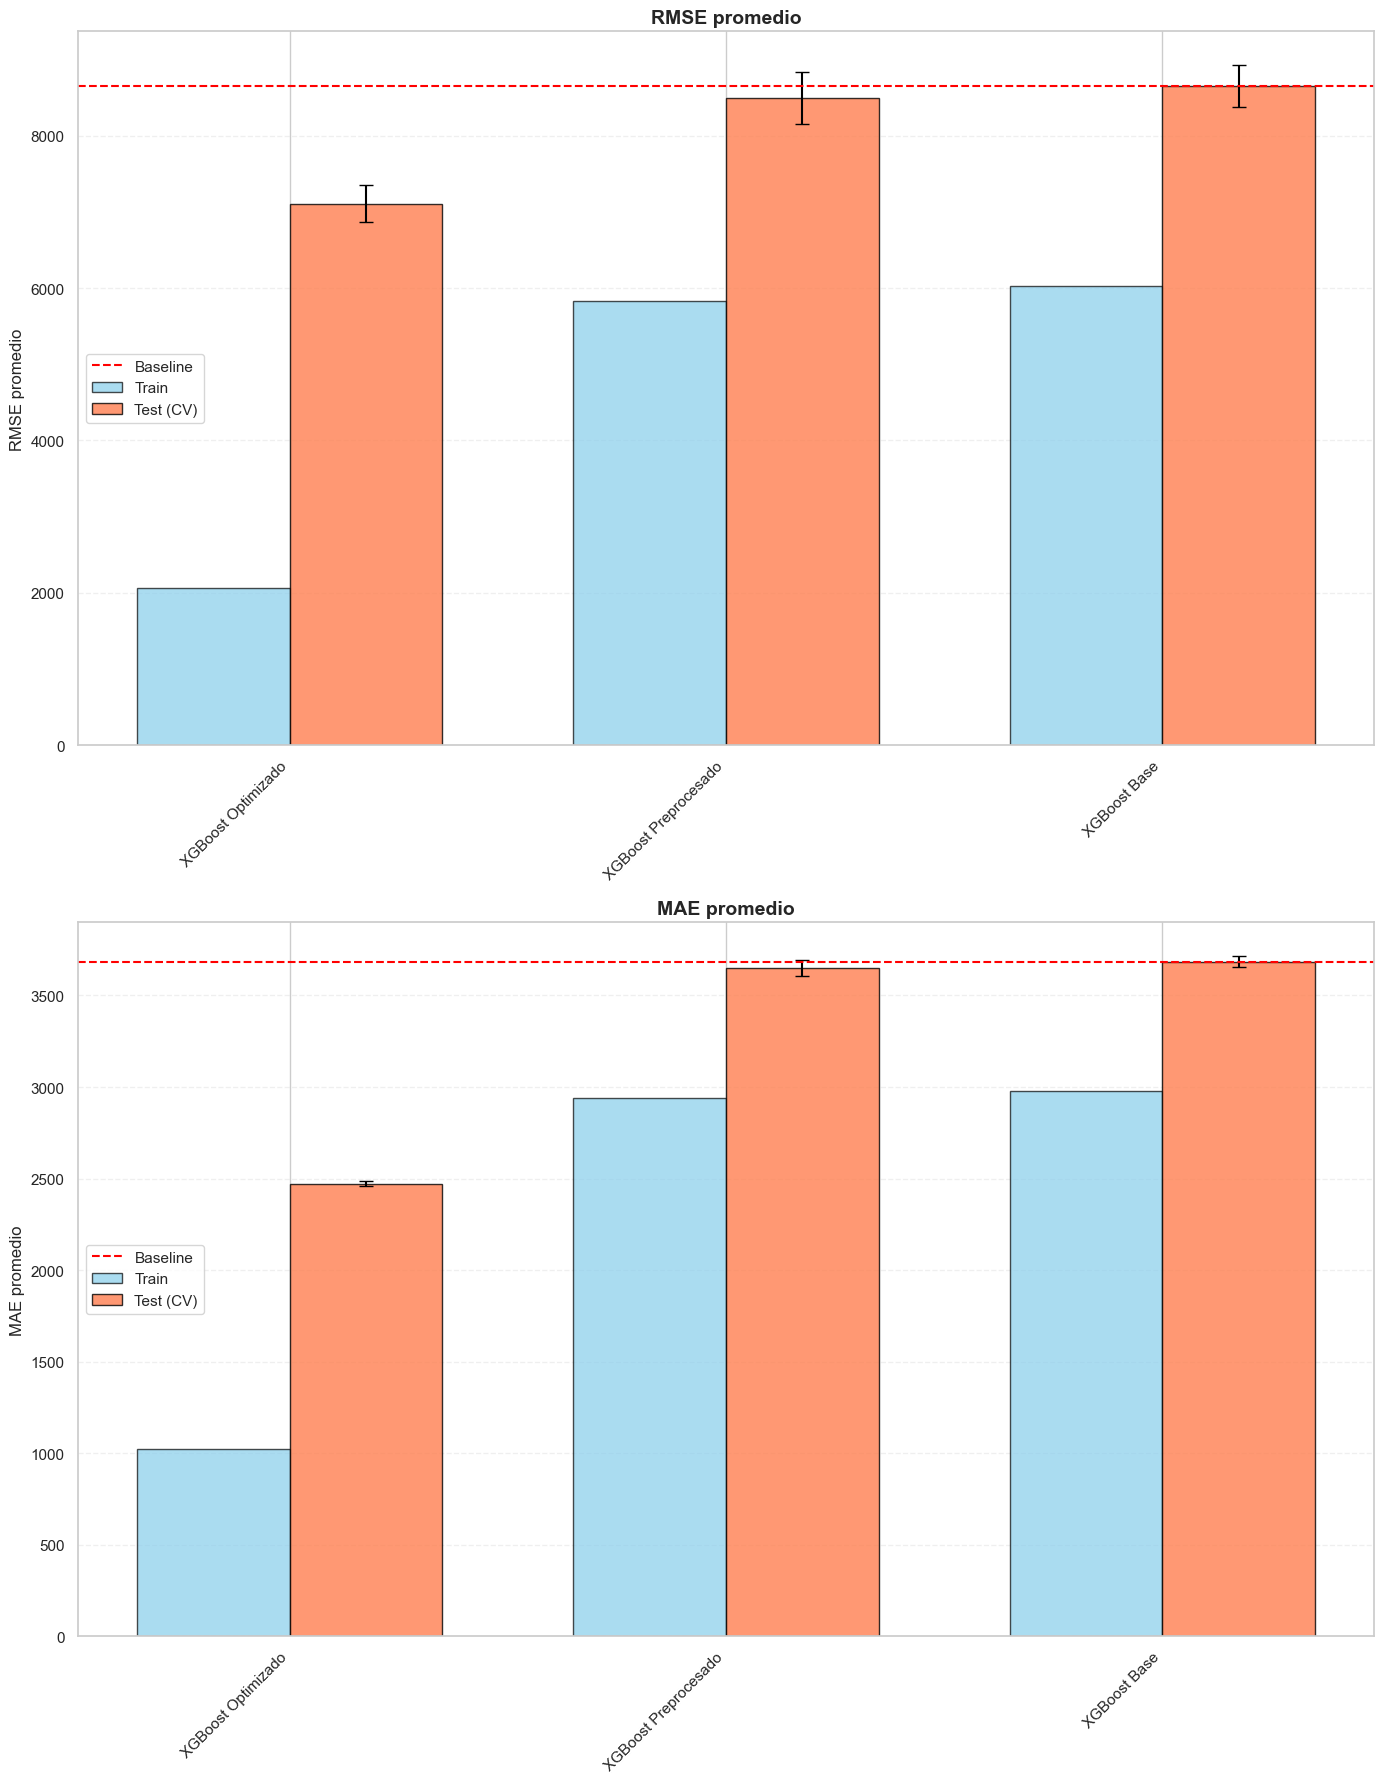

In [25]:
plot_cv_results(comparison_results, baseline_name="XGBoost Base")

## 2. Dataset Outliers

In [56]:
df_outliers = pd.read_csv("../" + DEV_SET_CLEAN_OUTLIERS_PATH)

X_outliers = df_outliers.drop(columns=TARGET)
y_outliers = df_outliers[TARGET]

X_train_outliers, X_val_outliers, y_train_outliers, y_val_outliers = train_test_split(
    X_outliers, y_outliers, test_size=0.2, random_state=42
)

feature_pipeline_outliers = build_feature_pipeline(TREE_BASED_CONFIG_OUTLIERS)
target_pipeline_outliers = build_target_pipeline(TREE_BASED_CONFIG_OUTLIERS)

## 2.1 XGBoost Outlieres

In [40]:
df_xgb_outliers = pd.read_csv("../results/random_search/xgb_outliers.csv")
df_xgb_outliers = add_id_to_results(df_xgb_outliers)

In [28]:
df_xgb_outliers.head()

,config_id,Unnamed: 0,colsample_bytree,gamma,learning_rate,max_depth,min_child_weight,n_estimators,reg_lambda,subsample,mae_mean,mae_std,rmse_mean,rmse_std,train_mae_mean,train_mae_std,train_rmse_mean,train_rmse_std,overfit_gap_%
0,1,946,0.813422,0.000121,0.082373,9,5,600,0.077491,0.666706,392505.464038,34993.569006,1.061922e+06,183820.824306,42594.171003,1930.664907,82265.105815,4768.968002,821.500418
1,2,794,0.961781,0.000374,0.188241,14,8,800,0.961579,0.785575,420401.969342,26850.086756,1.138849e+06,166106.804171,35374.680111,367.390209,68033.170259,2149.463635,1088.426208
2,3,338,0.623789,0.001584,0.202059,6,8,600,1.559495,0.702419,422736.632743,16695.244302,1.086091e+06,169404.042552,79475.782198,1401.560022,143613.602476,3789.473856,431.906225
3,4,908,0.789641,0.002053,0.013304,13,4,900,2.815822,0.977510,430765.285413,34361.811671,1.115861e+06,201871.616667,95392.685944,2733.292173,244910.212444,16588.790477,351.570559
4,5,714,0.618823,0.009724,0.066638,9,8,1000,2.285298,0.716102,433565.932022,32466.072502,1.076792e+06,186319.029102,134579.931747,1615.455968,256228.500954,10233.681355,222.162396


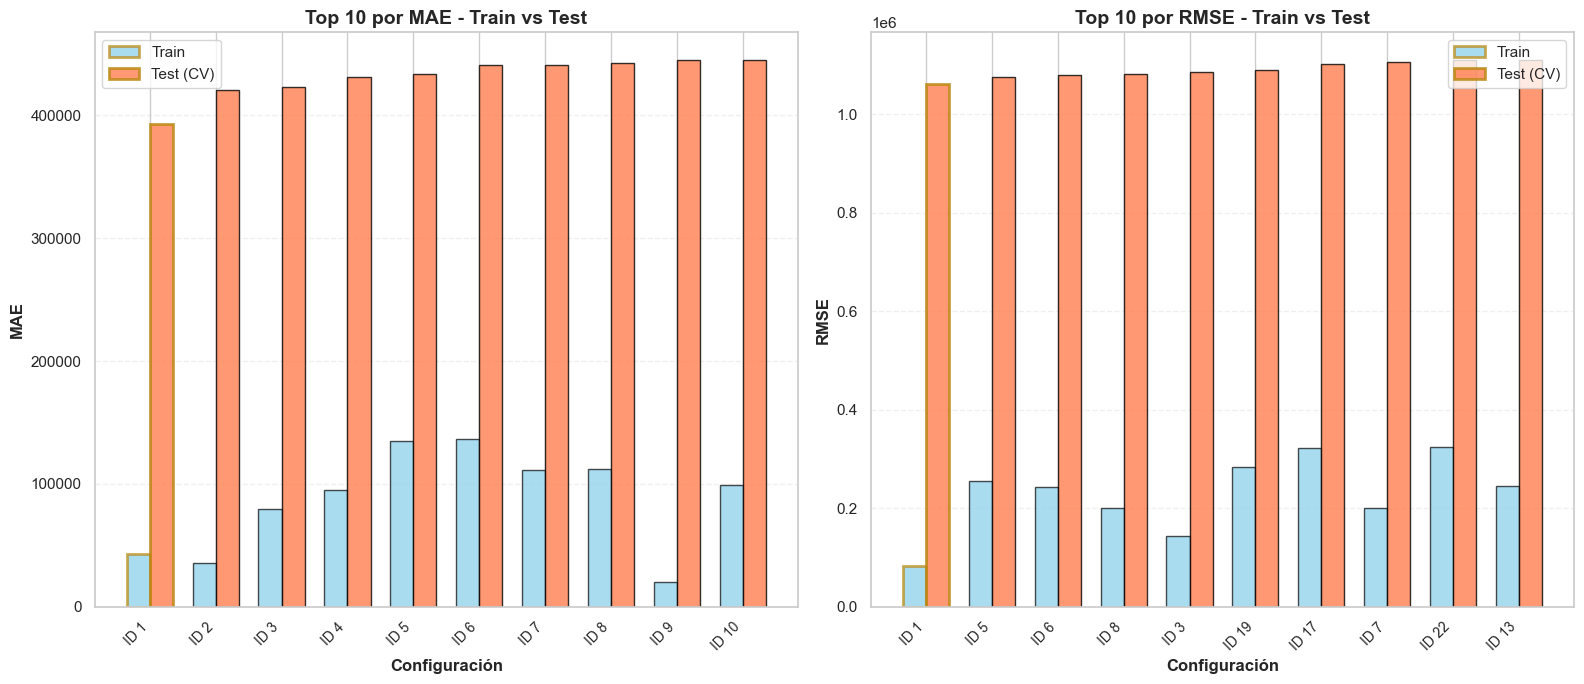

In [29]:
plot_grid_search_results(df_xgb_outliers, top_n=10)

## 2.2 LightGBM Outliers

In [30]:
df_lgbm_outliers = pd.read_csv("../results/random_search/lgbm_outliers.csv")
df_lgbm_outliers = add_id_to_results(df_lgbm_outliers)

In [31]:
df_lgbm_outliers.head()

,config_id,Unnamed: 0,colsample_bytree,learning_rate,min_child_samples,min_child_weight,min_data_in_leaf,n_estimators,num_leaves,path_smooth,...,subsample_freq,mae_mean,mae_std,rmse_mean,rmse_std,train_mae_mean,train_mae_std,train_rmse_mean,train_rmse_std,overfit_gap_%
0,1,680,0.581404,0.044048,5,0.333565,12,2000,17,1.911035,...,1,456023.197432,32268.981837,1.114908e+06,179438.491698,186822.508929,2988.341115,377734.645776,9291.864063,144.094355
1,2,811,0.893439,0.034366,11,0.461804,6,2000,17,0.584500,...,1,460988.547853,29166.470038,1.114961e+06,175280.009916,195682.798248,5002.003195,391583.792172,10733.295196,135.579495
2,3,654,0.581149,0.038045,19,0.076668,10,2000,16,1.884761,...,1,462238.293120,31076.758162,1.116204e+06,189987.097111,204457.017603,3606.893417,417515.054756,11309.692050,126.080914
3,4,156,0.627245,0.043723,13,0.436669,13,2000,17,0.933028,...,1,469446.713690,34203.697663,1.148710e+06,173442.810117,203323.069855,3002.622285,419926.100756,11912.543181,130.887087
4,5,114,0.841129,0.036631,9,0.030626,5,2000,18,0.567651,...,1,470377.842347,34417.034226,1.137847e+06,181555.764762,211572.888390,3415.044224,437773.798967,8635.125457,122.324252


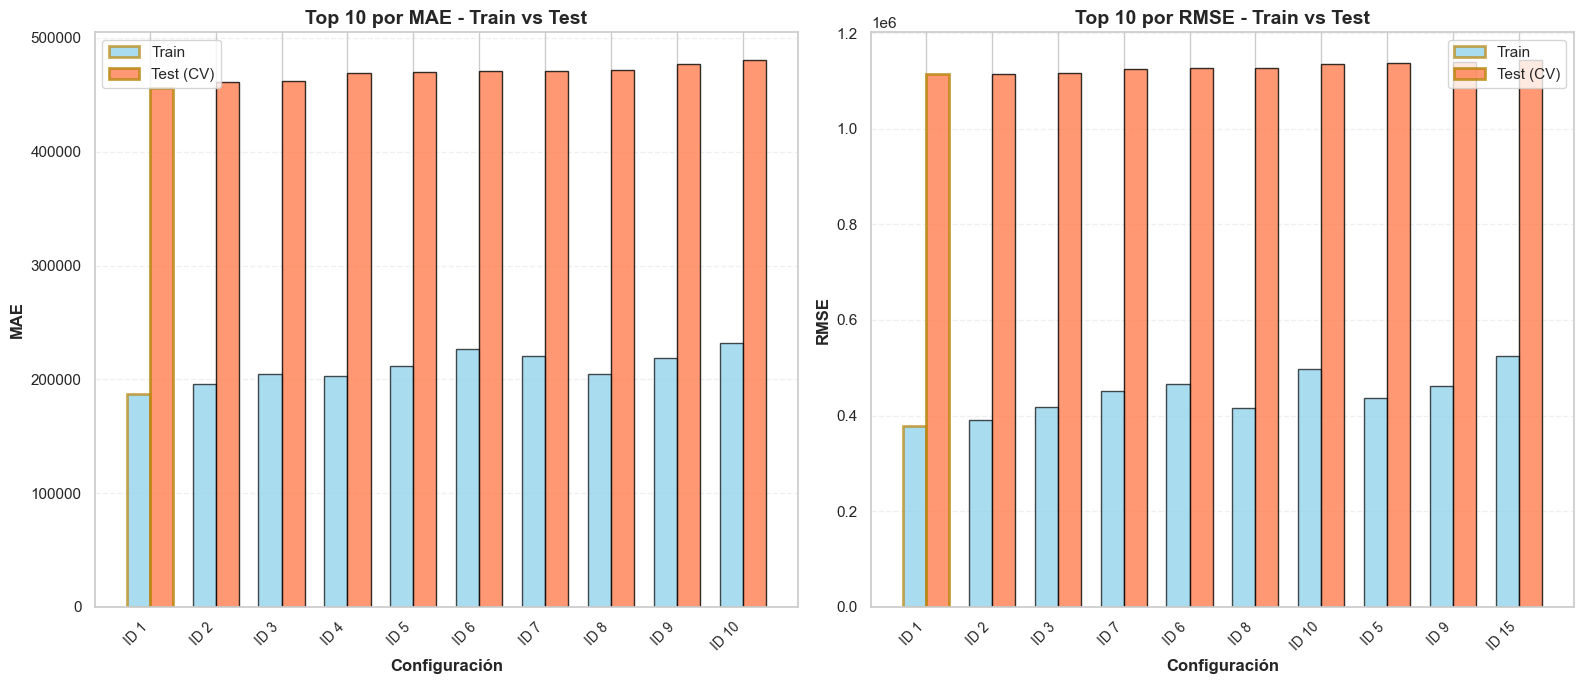

In [32]:
plot_grid_search_results(df_lgbm_outliers, top_n=10)

## 2.3 Modelo final para dataset de outliers
El XGBoost con ID 1 es el que tuvo las mejores métricas, pero la diferencia entre train y test es la peor hasta ahora. veamos su curva:

## 2.4 Comparación final para el dataset de outliers

In [68]:
base_xgboost_outliers_preprocessed_pipeline = get_base_xgboost(feature_pipeline_outliers)
base_xgboost_outliers_preprocessed = TransformedTargetRegressor(
    regressor=base_xgboost_outliers_preprocessed_pipeline, transformer=target_pipeline_outliers, check_inverse=False
)

best_xgboost_config_outliers = {
    'colsample_bytree': 0.8134217734214317,
    'gamma': 0.00012050234256727466,
    'learning_rate': 0.08237330081140835,
    'max_depth': 9,
    'min_child_weight': 5,
    'n_estimators': 600,
    'reg_lambda': 0.07749120913095153,
    'subsample': 0.6667057075490768,
}
best_xgboost_outliers_pipeline = Pipeline([("features", feature_pipeline_outliers), ("model", XGBRegressor(**best_xgboost_config_outliers))])
best_xgboost_outliers = TransformedTargetRegressor(
    regressor=best_xgboost_outliers_pipeline, transformer=target_pipeline_outliers, check_inverse=False
)

In [69]:
models_to_compare_outliers = {
    "XGBoost Base": base_xgboost,
    "XGBoost Preprocesado": base_xgboost_outliers_preprocessed,
    "XGBoost Optimizado": best_xgboost_outliers,
}

In [70]:
comparison_results_outliers = evaluate_models_cv(
    models_to_compare_outliers,
    X_outliers,
    y_outliers,
    feature_pipeline=None,
    target_pipeline=None,
    n_splits=5,
    verbose=True
)


🔄 Ejecutando 5-Fold Cross-Validation...

Entrenando XGBoost Base...
  ✓ MAE: 411,887 ± 22,734
  ✓ RMSE: 1,077,577 ± 204,090

Entrenando XGBoost Preprocesado...
  ✓ MAE: 404,304 ± 29,639
  ✓ RMSE: 1,111,646 ± 168,553

Entrenando XGBoost Optimizado...
  ✓ MAE: 390,231 ± 26,302
  ✓ RMSE: 1,053,702 ± 153,288



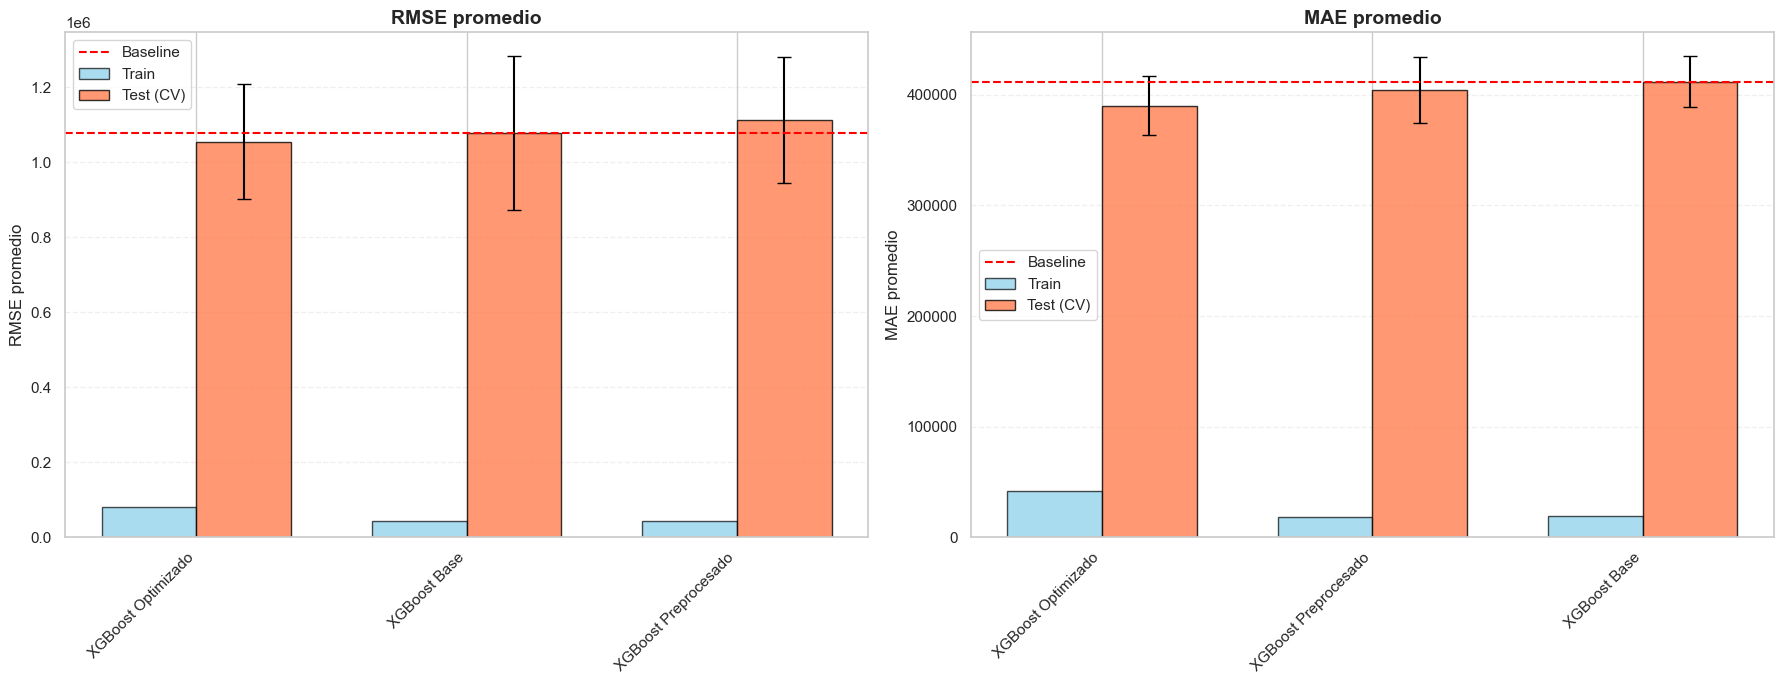

In [71]:
plot_cv_results(comparison_results_outliers, baseline_name="XGBoost Base", vertical_layout=False)

# 3. Dataset completo

In [84]:
df_full = pd.read_csv("../" + DEV_SET_CLEAN_PATH)

X_full = df_full.drop(columns=TARGET)
y_full = df_full[TARGET]

X_train_full, X_val_full, y_train_full, y_val_full = train_test_split(
    X_full, y_full, test_size=0.2, random_state=42
)

## 3.1 XGBoost Completo

In [85]:
df_xgb_full = pd.read_csv("../results/random_search/xgb_full.csv")
df_xgb_full = add_id_to_results(df_xgb_full)

In [86]:
df_xgb_full.head()

,config_id,Unnamed: 0,colsample_bytree,gamma,learning_rate,max_depth,min_child_weight,n_estimators,reg_lambda,subsample,mae_mean,mae_std,rmse_mean,rmse_std,train_mae_mean,train_mae_std,train_rmse_mean,train_rmse_std,overfit_gap_%
0,1,186,0.781516,0.118025,0.032049,14,1,900,1.243571,0.846858,60226.550769,384.323509,410998.350349,15258.721821,15230.942374,516.477708,94544.355498,8746.075416,295.422353
1,2,25,0.823317,0.441318,0.066612,14,3,600,3.629778,0.958844,69691.689966,264.027600,413924.519881,18703.061089,25354.377805,1217.809610,124428.592000,7244.604029,174.870441
2,3,199,0.843933,0.281719,0.124126,14,1,300,2.728434,0.777768,69889.315025,250.068464,414081.365768,14807.035845,21931.108206,575.416015,103543.238329,8097.783178,218.676623
3,4,66,0.741341,0.291828,0.033320,14,4,600,3.490809,0.814439,72271.657208,227.449120,409084.630115,21587.041604,43772.347960,996.068048,212019.149591,6014.760576,65.108020
4,5,158,0.720385,0.354086,0.030205,11,1,1000,3.104578,0.618297,74035.874788,245.247457,413421.697103,18365.333573,47108.054680,716.009009,207125.293942,6334.411594,57.161817


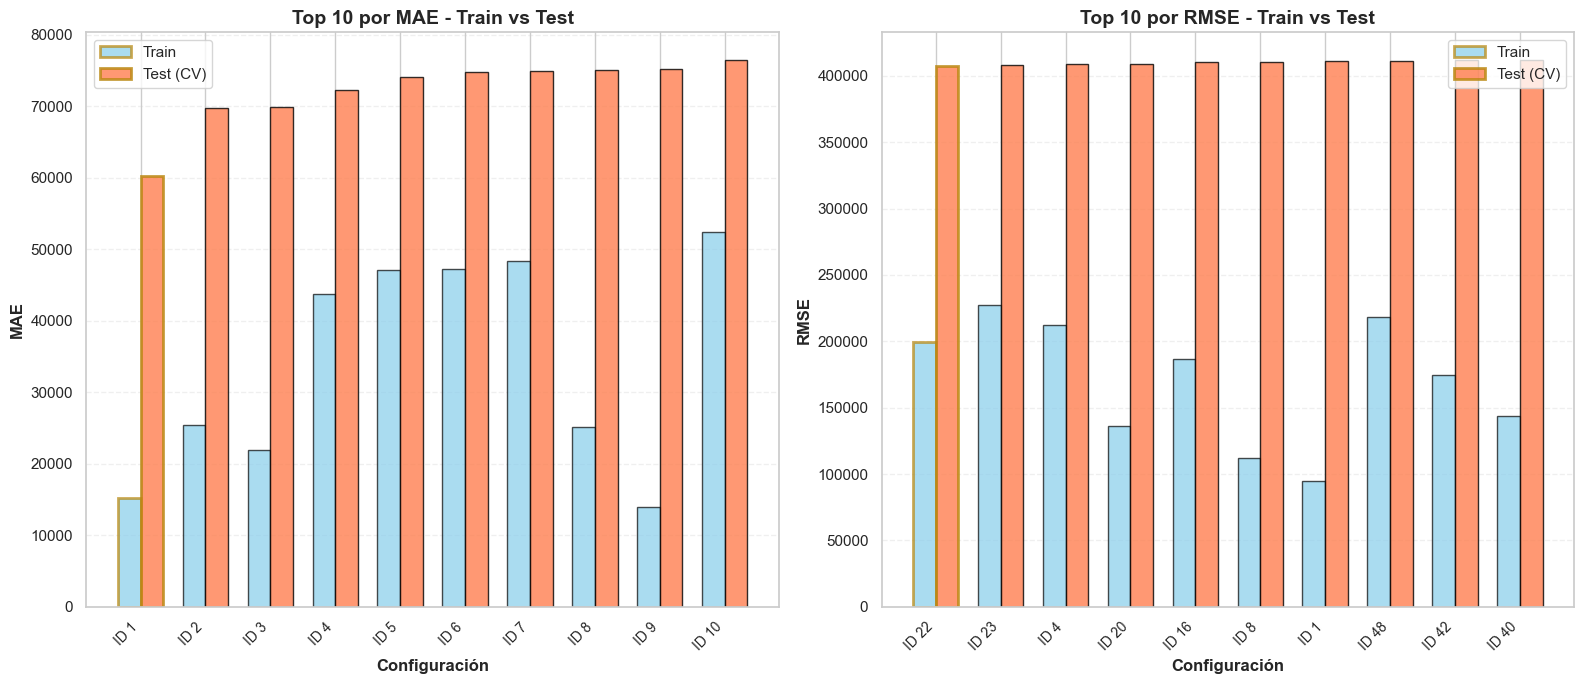

In [87]:
plot_grid_search_results(df_xgb_full, top_n=10)

## 3.2 LightGBM Completo

In [88]:
df_lgbm_full = pd.read_csv("../results/random_search/lgbm_full.csv")
df_lgbm_full = add_id_to_results(df_lgbm_full)
df_lgbm_full.head()

,config_id,Unnamed: 0,colsample_bytree,learning_rate,min_child_samples,min_child_weight,n_estimators,num_leaves,reg_alpha,reg_lambda,subsample,mae_mean,mae_std,rmse_mean,rmse_std,train_mae_mean,train_mae_std,train_rmse_mean,train_rmse_std,overfit_gap_%
0,1,271,0.656010,0.090276,10,9.009306,1200,44,0.980489,3.053900,0.712273,85821.588239,1105.235947,429655.154186,17995.118029,67677.735264,1289.745971,304554.453446,8591.483354,26.809191
1,2,108,0.703155,0.050413,13,2.645524,1200,43,1.361537,0.091953,0.965720,88058.911437,346.263669,445959.974848,15900.440849,74232.924788,1143.764719,354008.183181,9687.336348,18.625141
2,3,16,0.713936,0.020697,11,10.053580,1200,41,4.541329,1.197809,0.657958,88159.975074,199.455835,473945.985604,13659.119445,79684.599819,437.408931,412536.468402,8137.984044,10.636152
3,4,86,0.742145,0.123530,11,10.871057,800,48,0.584490,4.699161,0.851083,89088.131252,672.727025,431371.991351,17995.633858,70894.254060,1389.024292,310261.961490,10548.642446,25.663402
4,5,214,0.864548,0.063707,14,10.992321,500,47,0.413088,2.573288,0.959560,90569.583238,574.752509,468758.763021,14042.005731,80323.518638,936.879326,398948.470473,8960.452440,12.755996


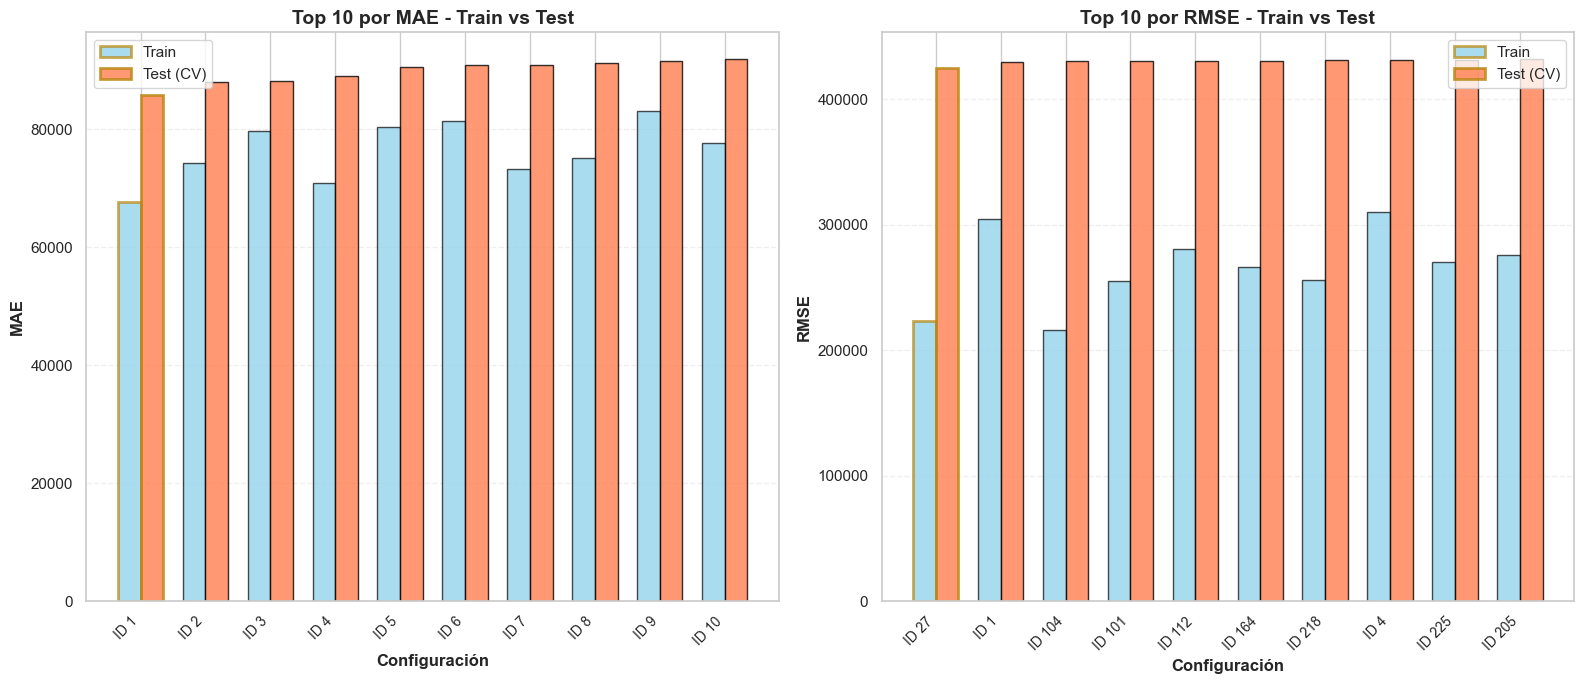

In [89]:
plot_grid_search_results(df_lgbm_full, top_n=10)

## 3.3 Mejor modelo para dataset completo
El modelo que mejor funcionó (estuvo entre los mejores RMSE y tuvo una mejora significativa sobre MAE) es:

In [90]:
best_xgboost_config_full = {
    'colsample_bytree': 0.7815158165534557,
    'gamma': 0.11802523167323198,
    'learning_rate': 0.032049024199003795,
    'max_depth': 14,
    'min_child_weight': 1,
    'n_estimators': 900,
    'reg_lambda': 1.2435713629381495,
    'subsample': 0.846857994641612,
}
best_xgboost_full_pipeline = Pipeline([("features", feature_pipeline), ("model", XGBRegressor(**best_xgboost_config_full))])
best_xgboost_full = TransformedTargetRegressor(
    regressor=best_xgboost_full_pipeline, transformer=target_pipeline, check_inverse=False
)

In [91]:
models_to_compare_full = {
    "XGBoost Base": base_xgboost,
    "XGBoost Preprocesado": base_xgboost_preprocessed,
    "XGBoost Optimizado": best_xgboost_full,
}

In [92]:
comparison_results_full = evaluate_models_cv(
    models_to_compare_full,
    X_full,
    y_full,
    feature_pipeline=None,
    target_pipeline=None,
    n_splits=5,
    verbose=True
)


🔄 Ejecutando 5-Fold Cross-Validation...

Entrenando XGBoost Base...
  ✓ MAE: 95,505 ± 1,864
  ✓ RMSE: 436,177 ± 44,519

Entrenando XGBoost Preprocesado...
  ✓ MAE: 93,855 ± 1,378
  ✓ RMSE: 431,724 ± 41,055

Entrenando XGBoost Optimizado...
  ✓ MAE: 56,526 ± 1,890
  ✓ RMSE: 397,773 ± 40,031



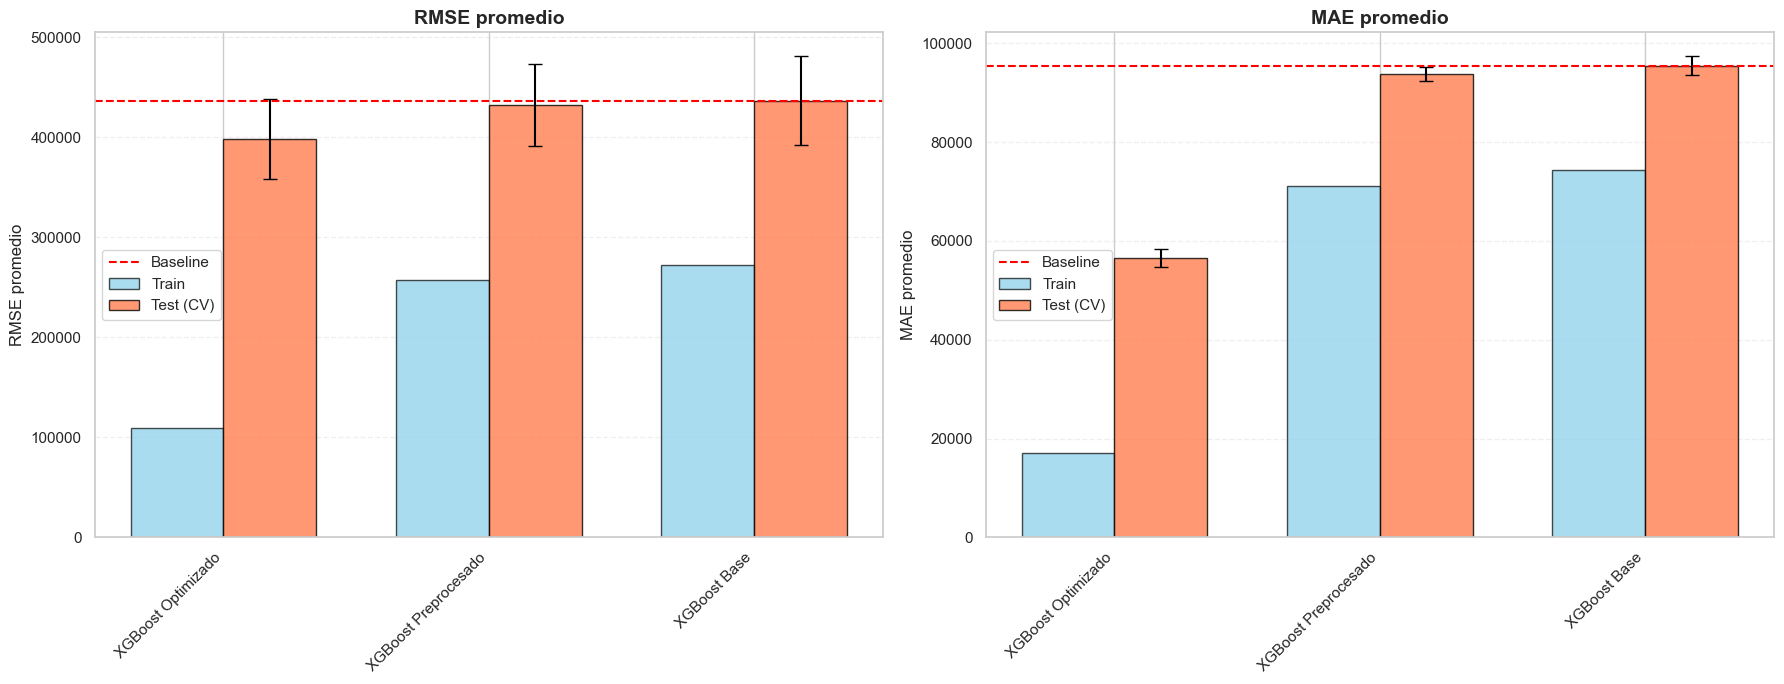

In [93]:
plot_cv_results(comparison_results_full, baseline_name="XGBoost Base", vertical_layout=False)

# Conclusiones

A continuación se detallan las configuraciones que mejor funcionaron para cada dataset

## Dataset Normal

In [1]:
best_xgboost_config_normal = {
    'colsample_bytree': 0.7545843364636589,
    'gamma': 0.2822205453394412,
    'learning_rate': 0.0675347366775581,
    'max_depth': 14,
    'min_child_weight': 2,
    'n_estimators': 700,
    'reg_lambda': 4.9743315858488355,
    'subsample': 0.6231122243985466
}

## Dataset Outliers

In [ ]:
best_xgboost_config_outliers = {
    'colsample_bytree': 0.8134217734214317,
    'gamma': 0.00012050234256727466,
    'learning_rate': 0.08237330081140835,
    'max_depth': 9,
    'min_child_weight': 5,
    'n_estimators': 600,
    'reg_lambda': 0.07749120913095153,
    'subsample': 0.6667057075490768,
}

## Datset Completo

In [2]:
best_xgboost_config_full = {
    'colsample_bytree': 0.7815158165534557,
    'gamma': 0.11802523167323198,
    'learning_rate': 0.032049024199003795,
    'max_depth': 14,
    'min_child_weight': 1,
    'n_estimators': 900,
    'reg_lambda': 1.2435713629381495,
    'subsample': 0.846857994641612,
}